# Final Project

*Made by Diego Plumed Beortegui*

*March 2026*

### Assessment Task: Glass Classification with K-Nearest Neighbours (KNN)

You will write two separate, complete scripts: one for Glass (Type) classification and one for Zoo animals (class_type) classification using KNN.
Both scripts  should include: split → scale → choose best k via 10-fold CV on training → train final model → evaluate (accuracy + confusion matrix + report).



By completing this task, students will be able to:

	- 1.	Load and inspect a dataset for supervised classification.
	- 2.	Perform appropriate EDA for numerical features and a categorical target.
	- 3.	Apply correct preprocessing (train/test split + scaling).
	- 4.	Train and tune a KNN model using cross-validation and GridSearch.
	- 5.	Evaluate and interpret results using confusion matrices and classification metrics.

# Data 

You are given a dataset (glass.csv) containing chemical and physical measurements of glass samples. Your goal is to build and evaluate a KNN classifier that predicts the glass Type (multi-class classification). Use skleanr library as suggested in the given code.

# Data Description:

RI : refractive index

Na : Sodium (unit measurement: weight percent in corresponding oxide, as are attributes 4-10)

Mg : Magnesium

AI : Aluminum

Si : Silicon

K  : Potassium

Ca : Calcium

Ba : Barium

Fe : Iron

Type : Type of glass : (class attribute)
 * 1 -- building_windows_float_processed
 * 2 -- building_windows_non_float_processed
 * 3 -- vehicle_windows_float_processed
 * 4 -- vehicle_windows_non_float_processed (none in this database)
 * 5 -- containers
 * 6 -- tableware
 * 7 -- headlamps

## 1. Import Libraries

In [70]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold

import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading and Understanding (10 marks)

1.	Load glass.csv into a pandas DataFrame.

2.	Display:

	-- •	`info()`

	-- •	missing values summary

	-- •	`describe()`

3.	Show class distribution for Type (counts + plot).

In [71]:
glass_df = pd.read_csv('glass.csv')
glass_df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [72]:
glass_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


From the previous information table, we note that the glass dataset does not contain any missing values. We check again nevertheless.

In [73]:
glass_df.isnull().values.any()

np.False_

We summarise them the following table.

In [74]:
missing_summary = pd.DataFrame({
    'Missing Values': glass_df.isnull().sum(),
    'Percentage (%)': glass_df.isnull().mean() * 100
})

print(missing_summary)

      Missing Values  Percentage (%)
RI                 0             0.0
Na                 0             0.0
Mg                 0             0.0
Al                 0             0.0
Si                 0             0.0
K                  0             0.0
Ca                 0             0.0
Ba                 0             0.0
Fe                 0             0.0
Type               0             0.0


In [75]:
glass_df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


We display the class counts:

In [76]:
glass_df['Type'].value_counts().sort_index()

Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64

The values are indeed coherent with the statistical information provided by `glass_df.describe()`. We construct a barplot to visualise them.

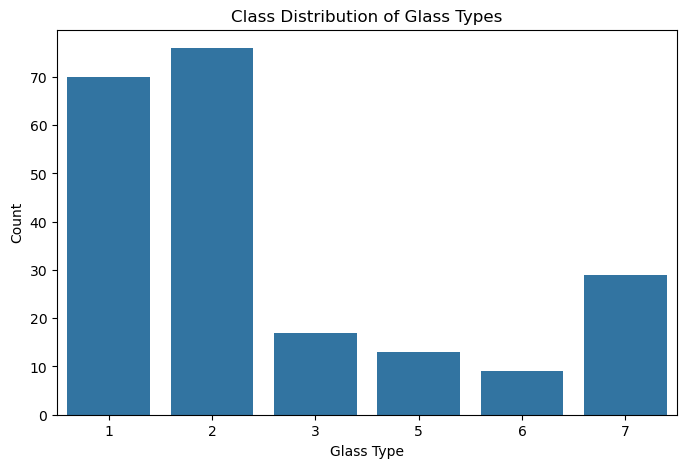

In [77]:
plt.figure(figsize=(8,5))
sns.countplot(x='Type', data=glass_df, order=sorted(glass_df['Type'].unique()))

plt.title('Class Distribution of Glass Types')
plt.xlabel('Glass Type')
plt.ylabel('Count')
plt.show()

## 3. Data Understanding

**Task:** Use an appropriate pandas function to display the first five rows of the dataset and briefly describe the variables shown, etc.

In [78]:
glass_df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


All the first five variables correspond to type 1 glass.  

In [79]:
glass_df[0:5].describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.0,5.0,5.0
mean,1.517976,13.508000,3.790000,1.306000,72.638000,0.410000,8.130000,0.0,0.0,1.0
std,0.001801,0.278065,0.394525,0.161802,0.515917,0.207966,0.390064,0.0,0.0,0.0
min,1.516180,13.210000,3.550000,1.100000,71.780000,0.060000,7.780000,0.0,0.0,1.0
25%,1.517420,13.270000,3.600000,1.240000,72.610000,0.390000,7.830000,0.0,0.0,1.0
50%,1.517610,13.530000,3.620000,1.290000,72.730000,0.480000,8.070000,0.0,0.0,1.0
75%,1.517660,13.640000,3.690000,1.360000,72.990000,0.550000,8.220000,0.0,0.0,1.0
max,1.521010,13.890000,4.490000,1.540000,73.080000,0.570000,8.750000,0.0,0.0,1.0


They share noticeable similarities: their component distributions are really similar (that is, their standard deviation is low with respect to their respective magnitudes), and none possess either barium or iron.

In [80]:
#run this
glass_df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

- 1. **What is the meaning of : `glass_df.isnull()`?**

In [81]:
glass_df.isnull()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
209,False,False,False,False,False,False,False,False,False,False
210,False,False,False,False,False,False,False,False,False,False
211,False,False,False,False,False,False,False,False,False,False
212,False,False,False,False,False,False,False,False,False,False


In [82]:
type(glass_df.isnull())

pandas.core.frame.DataFrame

**Answer:**
`glass_df.isnull()`It is a DataFrame with the same structure as *glass_df* but storing a boolean in each entry indicating whether that entry contains a NaN value (True) or not (False).

- 2. **Why do we sum the output? (.sum)**

**Answer:** `.sum()` sums all the entries of the preceding structure. In this case, it will treat the ones from `glass_df.isnull()` as 1 if True and 0 if False. Therefore, it will end up being a counter of the NaN objects in our dataset.

- 3. **Why is it important to remove NaN values if any from the dataset?**

**Answer:** For starters, a DataFrame containing NaN values may not be compatible with some functions. In the case that the function does accept arguments containing NaN values, they are discarded for the computations, which may lead to unrepresentative and biased results. In our particular case, we want to classify through clusters derived from the Euclidean distance and, thus, NaN values would not have any coherent interpretation and would not fit the method. Furthermore, `KNeighborsClassifier()` does not accept inputs containing NaN values.

You are given a dataset glass_df containing measurements of glass samples. Before building any machine learning model, it is critical to ensure data quality. One common data issue is duplicate records. Duplicate rows can:

	- •	Bias model training
	- •	Artificially inflate accuracy
	- •	Distort distance-based models like KNN

Your task is to identify, analyze, and remove duplicate records appropriately.  (Add annotations for this task)


We check if there is any duplicated data.

In [83]:
glass_df.duplicated()       # Provides an array indicating if the row is repeted (True) or not (False).

0      False
1      False
2      False
3      False
4      False
       ...  
209    False
210    False
211    False
212    False
213    False
Length: 214, dtype: bool

In [84]:
glass_df[glass_df.duplicated()]     # We consider the duplicated rows.

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
39,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1


In [85]:
glass_df.drop_duplicates(inplace=True)      # We remove such rows.

**Good practice:** Important to Verify After Removal (You should now see: Remaining duplicates: 0)

In [86]:
print("New shape:", glass_df.shape)
print("Remaining duplicates:", glass_df.duplicated().sum())

New shape: (213, 10)
Remaining duplicates: 0


In [87]:
glass_df.describe()     # We check the correct and unbiased by duplicates statistic metrics.

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000
mean,1.518348,13.404085,2.679202,1.449484,72.655070,0.498873,8.954085,0.175869,0.057277,2.788732
std,0.003033,0.816662,1.443691,0.495925,0.773998,0.653185,1.425882,0.498245,0.097589,2.105130
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516520,12.900000,2.090000,1.190000,72.280000,0.130000,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.560000,8.600000,0.000000,0.000000,2.000000
75%,1.519150,13.810000,3.600000,1.630000,73.090000,0.610000,9.150000,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


You were given the following code: `glass_df["Type"].unique()`

- 1. **Explain what this command does.**

In [88]:
glass_df["Type"].unique()

array([1, 2, 3, 5, 6, 7])

It returns an array containing a unique different value of the one provided.

- 2.	**What type of object does .unique() return?**

In [89]:
type(glass_df["Type"].unique())

numpy.ndarray

It returns a numpy array.

- 3.   **How many classes are present in the dataset?**

From the output of the command `glass_df["Type"].unique()`, we detect six different classes in our dataset: 1, 2, 3, 5, 6, and 7.

- 4.   **Is this a binary or multi-class classification problem?**

Since we are dealing with more than two classes, we are facing a multi-class classification problem.

- 5.   **What might the absence of class 4 suggest?**

It may suggest that the data provider does not process vehicle windows using the non-flat method, or there might have been a problem in the data extraction and the portion of data corresponding to type 4 was lost.

## 4. Exploratory Data Analysis

### Outliers Detection

**Task:** This is a sample code to check for outliers in the 'RI' column using a boxplot. You should  modify it to check for other columns as needed. All  columns in the same figure!

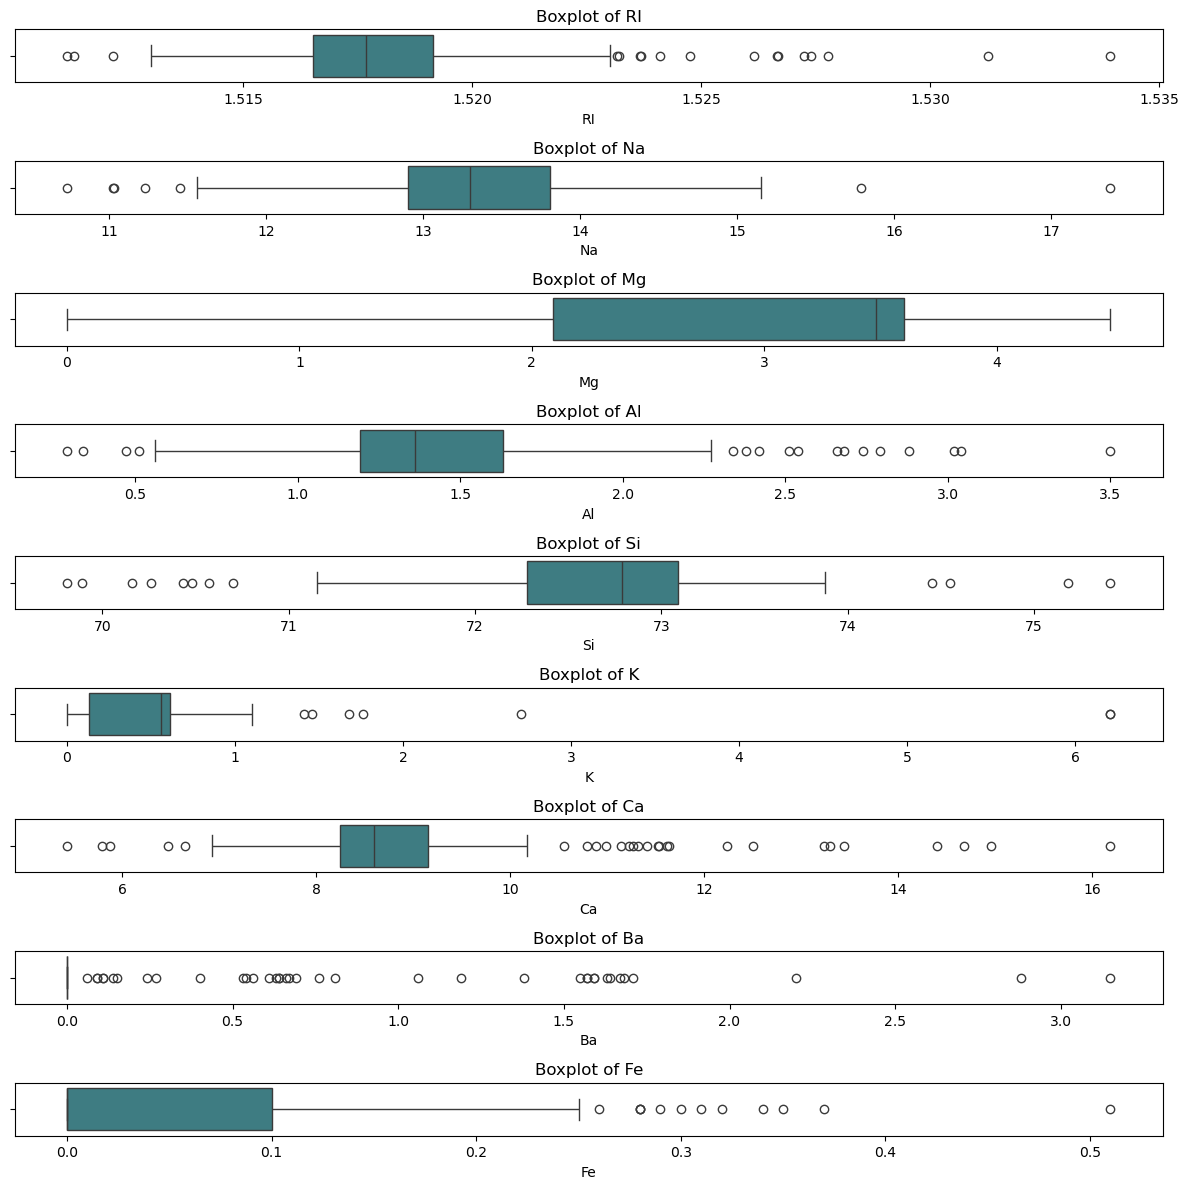

In [90]:

# Hint:fig, axes=plt.subplots(9,1,figsize=(12,12),sharex=False,sharey=False)
# sns.boxplot(x='RI',data=outlier,palette='crest',ax=axes[0]) 
#....

outlier = glass_df.copy()

fig, ax = plt.subplots(9, 1, 
                       figsize=(12,12),
                       sharex=False,
                       sharey=False)

columns = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

for i, col in enumerate(columns):
    sns.boxplot(
        x=outlier[col],
        palette='crest',
        ax=ax[i]
    )
    ax[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

 - 1. **Demonstrate with a plot , that the mean concentration of Silicon is substantially higher than all other features.**


In [91]:
help(np.mean)

Help on _ArrayFunctionDispatcher in module numpy:

mean(a, axis=None, dtype=None, out=None, keepdims=<no value>, *, where=<no value>)
    Compute the arithmetic mean along the specified axis.

    Returns the average of the array elements.  The average is taken over
    the flattened array by default, otherwise over the specified axis.
    `float64` intermediate and return values are used for integer inputs.

    Parameters
    ----------
    a : array_like
        Array containing numbers whose mean is desired. If `a` is not an
        array, a conversion is attempted.
    axis : None or int or tuple of ints, optional
        Axis or axes along which the means are computed. The default is to
        compute the mean of the flattened array.

        If this is a tuple of ints, a mean is performed over multiple axes,
        instead of a single axis or all the axes as before.
    dtype : data-type, optional
        Type to use in computing the mean.  For integer inputs, the default
    

In [92]:
features = glass_df.drop(columns=["Type"])
features_means = np.mean(features, axis=0)
features_means

RI     1.518348
Na    13.404085
Mg     2.679202
Al     1.449484
Si    72.655070
K      0.498873
Ca     8.954085
Ba     0.175869
Fe     0.057277
dtype: float64

<BarContainer object of 9 artists>

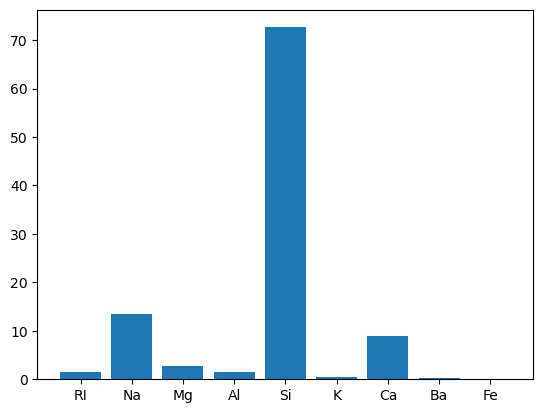

In [93]:
features_names = features.columns

plt.bar(features_names, features_means)

Indeed, the Silicon mean is considerably greater than the rest.

 - 2. **Is this necessarily a data quality issue? Justify your answer.**

Not necessarily, it represents a key aspect of the real proportions that windows follow. Thus, it is a coherent feature which encapsulates important information about the chemical relations of a window’s components, not a distorted one resulting from any data quality issue.

 - 3. **Should this feature be removed, transformed, or scaled before training a KNN model? Explain your reasoning.**


Certainly not removed, since it may contain crucial information to differentiate one window type from another. A non linear transformation may add noise and possibly remove meaningful patterns in the feature distribution. On the other hand, in this case, scaling the data is essential before applying KNN, a distance based method. The significant difference between Silicon's mean and the rest would lead to Silicon being a much more influential feature than the others, since it biases the whole feature space and, therefore, would be determinative when computing relative distances.

 - 4. **How might this affect model performance if scaling is not applied?**

The model would not capture all the information provided by the data, as it would be eclipsed by the biased Silicon feature. Thus, noise would be introduced, and performance would consequently be reduced.

## Multivariate Analysis
* You are given the dataset glass_df, which contains numerical chemical composition features and a target variable Type.

* Understanding relationships between features is important before building a machine learning model. In this task, you will compute, visualize, and interpret the correlation matrix.

	- 1.	Compute the correlation matrix for all numerical features (exclude the target variable if appropriate).
	- 2.	Display the correlation matrix as a heatmap with annotations.

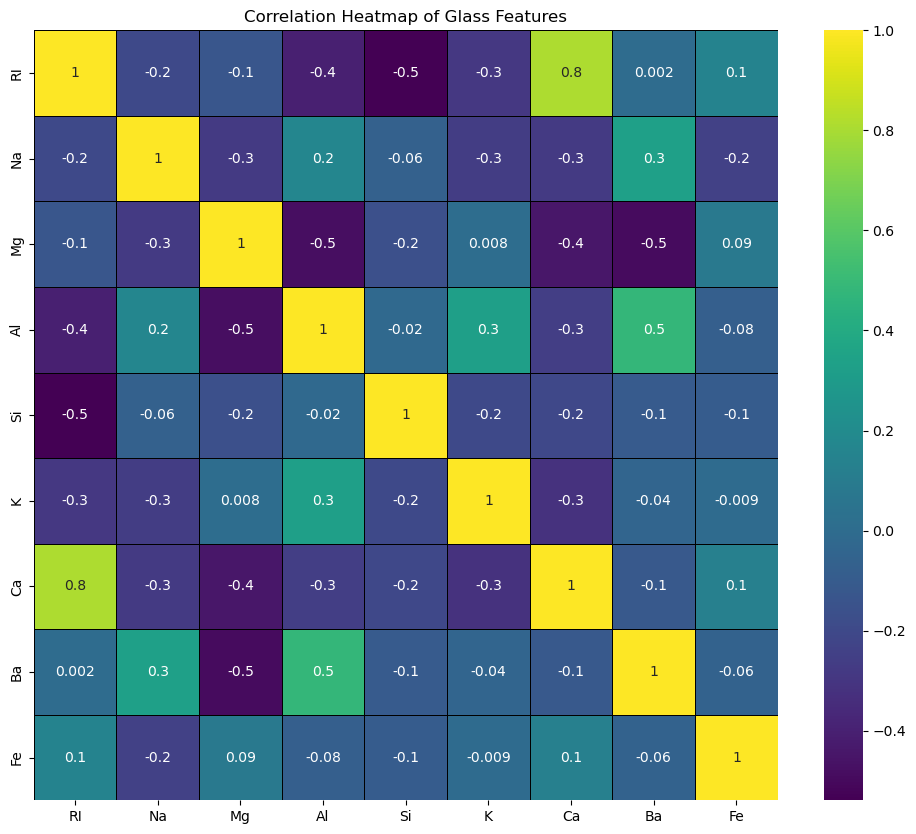

In [94]:
fig, ax = plt.subplots(figsize=(12,10))

sns.heatmap(features.corr(), 
            annot=True,         # Add annotations so correlation values on the heatmap are shown.
            fmt='.1g', 
            cmap="viridis",
            linewidths=0.5, 
            linecolor='black',
            ax = ax)

plt.title("Correlation Heatmap of Glass Features")
plt.show()

**Question:** Confusion Matrix — Why You Need It?

It is a useful tool since it intuitively relates the data features through the information they provide in a visual and descriptive diagram. Recall that the correlation between two features represents how close they are to being a linear combination of each other. Thus, according to their correlation, one may conclude that two variables would increase together (if their correlation is positive), behave in the opposite way (if their correlation is negative), or have independent behavior (if their correlation is 0). In our particular setting, we note that Calcium and the reflective index are highly correlated; that is, their correlation is close to 1: 0.8. Therefore, we may conclude that the information provided by both quantities is partially equivalent, and in the case of needing dimension reduction, we could remove one of these; its information would already be provided by the other.

###

You are given the following code:

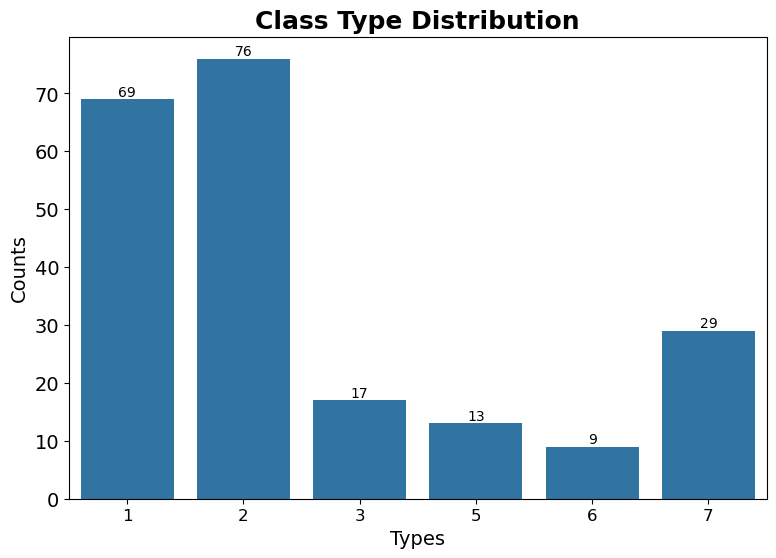

In [95]:
plt.figure(figsize = (9,6))
ax = sns.barplot(x = glass_df['Type'].value_counts().index.tolist(), y = glass_df['Type'].value_counts().tolist())
plt.yticks(fontsize = 14)
plt.xticks(fontsize = 12)
plt.title("Class Type Distribution",  fontsize = 18, fontweight = 'bold')
plt.xlabel('Types',fontsize = 14)
plt.ylabel('Counts',fontsize = 14)
for i in ax.containers:
    ax.bar_label(i,)

- 1.	**What does `glass_df['Type'].value_counts()` compute?**

In [96]:
glass_df['Type'].value_counts()

Type
2    76
1    69
7    29
3    17
5    13
6     9
Name: count, dtype: int64

In [97]:
type(glass_df['Type'].value_counts())

pandas.core.series.Series

In [98]:
help(glass_df['Type'].value_counts())

Help on Series in module pandas.core.series object:

class Series(pandas.core.base.IndexOpsMixin, pandas.core.generic.NDFrame)
 |  Series(data=None, index=None, dtype: 'Dtype | None' = None, name=None, copy: 'bool | None' = None, fastpath: 'bool | lib.NoDefault' = <no_default>) -> 'None'
 |
 |  One-dimensional ndarray with axis labels (including time series).
 |
 |  Labels need not be unique but must be a hashable type. The object
 |  supports both integer- and label-based indexing and provides a host of
 |  methods for performing operations involving the index. Statistical
 |  methods from ndarray have been overridden to automatically exclude
 |  missing data (currently represented as NaN).
 |
 |  Operations between Series (+, -, /, \*, \*\*) align values based on their
 |  associated index values-- they need not be the same length. The result
 |  index will be the sorted union of the two indexes.
 |
 |  Parameters
 |  ----------
 |  data : array-like, Iterable, dict, or scalar value


**Answer:** It computes a one dimensional pandas labeled array containing the counts of every distinct value that the input array has.

- 2.	**Why are .index.tolist() and .tolist() used in the barplot?**

In [99]:
glass_df['Type'].value_counts().index.tolist()

[2, 1, 7, 3, 5, 6]

In [100]:
glass_df['Type'].value_counts().tolist()

[76, 69, 29, 17, 13, 9]

**Answer:** `.index` is used to retrieve the index labels from the pandas Series, and .tolist() is used to convert the pandas objects back to Python lists, the type of argument expected by `sns.barplot()`.

- 3.	**What does ax.bar_label(i) add to the visualization?**

Text(0, 0.5, 'Counts')

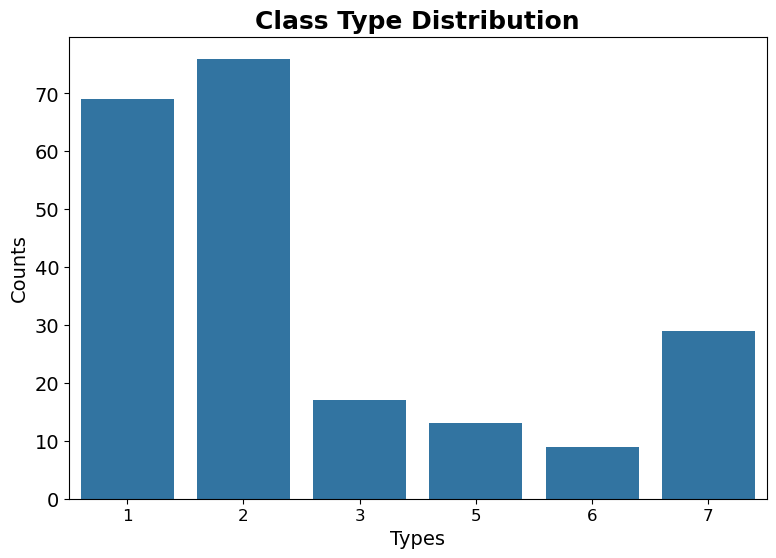

In [101]:
plt.figure(figsize = (9,6))
ax = sns.barplot(x = glass_df['Type'].value_counts().index.tolist(), y = glass_df['Type'].value_counts().tolist())
plt.yticks(fontsize = 14)
plt.xticks(fontsize = 12)
plt.title("Class Type Distribution",  fontsize = 18, fontweight = 'bold')
plt.xlabel('Types',fontsize = 14)
plt.ylabel('Counts',fontsize = 14)


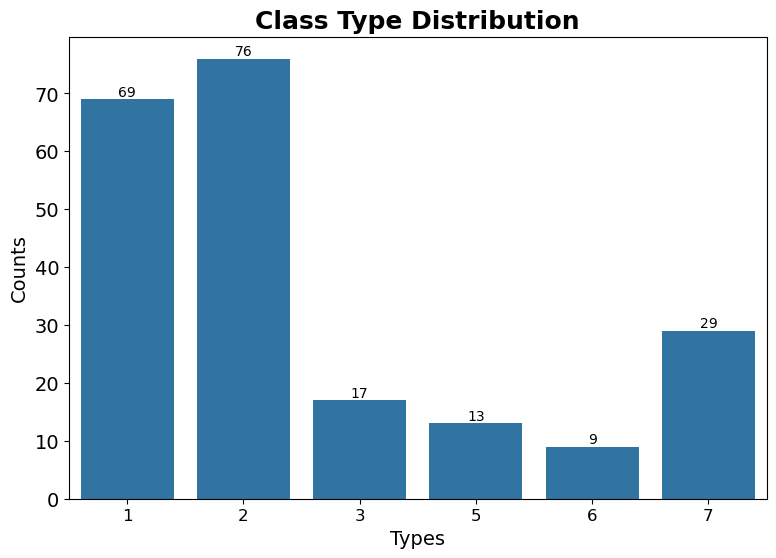

In [102]:
plt.figure(figsize = (9,6))
ax = sns.barplot(x = glass_df['Type'].value_counts().index.tolist(), y = glass_df['Type'].value_counts().tolist())
plt.yticks(fontsize = 14)
plt.xticks(fontsize = 12)
plt.title("Class Type Distribution",  fontsize = 18, fontweight = 'bold')
plt.xlabel('Types',fontsize = 14)
plt.ylabel('Counts',fontsize = 14)
for i in ax.containers:
    ax.bar_label(i,)

**Answer:** It adds the label on top of the bar plot columns, which shows the exact count of each window type.

###

After running this code, you observe that some classes have significantly fewer samples than others.

- 4.	**What does this indicate about the dataset?**

It indicates that the dataset is highly unbalanced, possibly because the data providers focus mainly on building windows and, hence, have much more data concerning them.

- 5.	**What is the potential issue this may cause when training a classifier?**

The algorithm may learn and capture more patterns of type 1 and 2 objects thanks to the amount of data provided for them and, on the other hand, may not retain enough important information regarding the rest. This could lead to overfitting on type 1 and 2 and, hence, misclassification of the other types.

- 6.	**Which evaluation metrics become more important in this situation?**

Due to the latter reasoning, accuracy will not be a meaningful evaluation metric, since it could misleadingly be high thanks to just type 1 and 2 predictions, failing to predict any others. In this case, precision and recall play a more significant role. Recall that the first measures how many predicted positives are actually correct, and the second measures how many actual positives are correctly predicted.

## 5. Data Pre-Processing

### 5.1 Hunting and removing multiple outliers
* Let's remove the observations containing multiple outliers with the function we created in the previous section.

In [103]:
# Detect observations with more than one outlier
features = glass_df.columns[:-1].tolist()
def outlier_hunt(df):
    """
    Takes a dataframe df of features and returns a list of the indices
    corresponding to the observations containing more than 2 outliers. 
    """
    outlier_indices = []
    
    # iterate over features(columns)
    for col in df.columns.tolist():
        Q1 = np.percentile(df[col], 25) # 1st quartile (25%)
        Q3 = np.percentile(df[col], 75) # 3rd quartile (75%)
        IQR = Q3 - Q1# Interquartile rrange (IQR)
        outlier_step = 1.5 * IQR # outlier step
        
        # Determine a list of indices of outliers for feature col
        outlier_list_col = df[(df[col] < Q1 - outlier_step) | (df[col] > Q3 + outlier_step )].index
        
        # append the found outlier indices for col to the list of outlier indices 
        outlier_indices.extend(outlier_list_col)
        
    # select observations containing more than 2 outliers
    outlier_indices = Counter(outlier_indices)        
    multiple_outliers = list( k for k, v in outlier_indices.items() if v > 2 )
    
    return multiple_outliers   

print('The dataset contains %d observations with more than 2 outliers' %(len(outlier_hunt(glass_df[features])))) 

The dataset contains 14 observations with more than 2 outliers


In [104]:
outlier_indices = outlier_hunt(glass_df[features])
df = glass_df.drop(outlier_indices).reset_index(drop=True)
print(df.shape)
df.head()

(199, 10)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


The following step:

For each feature:

	- 1•	Plots the distribution before outlier removal.
	- 2•	Plots the distribution after outlier removal.
	- 3•	Computes and displays skewness.
    

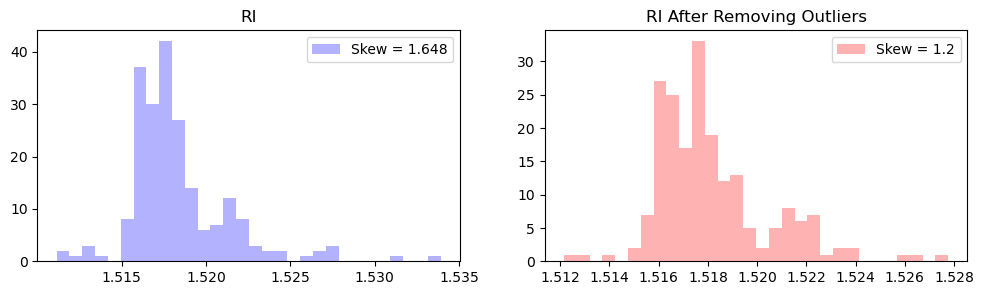

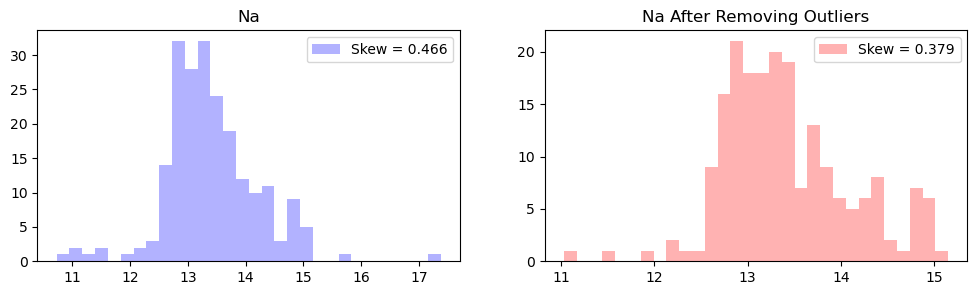

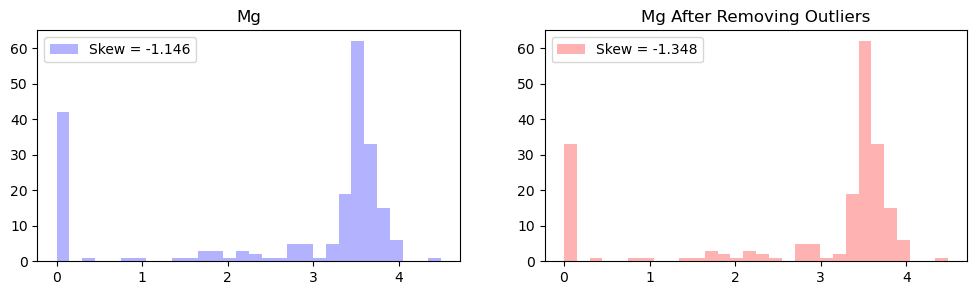

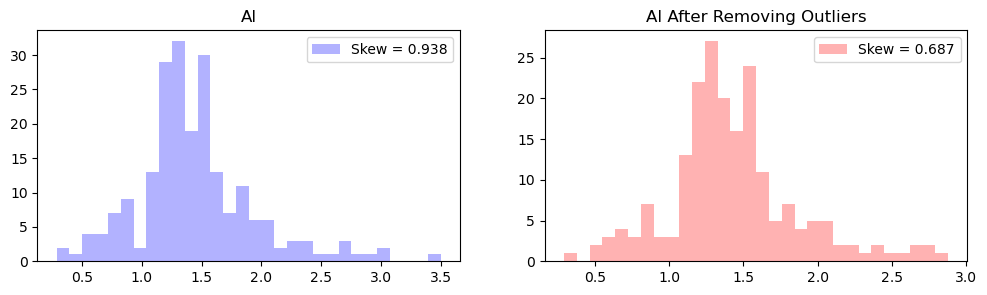

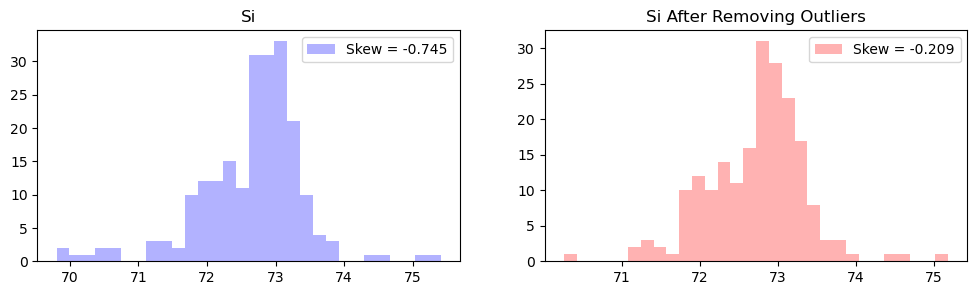

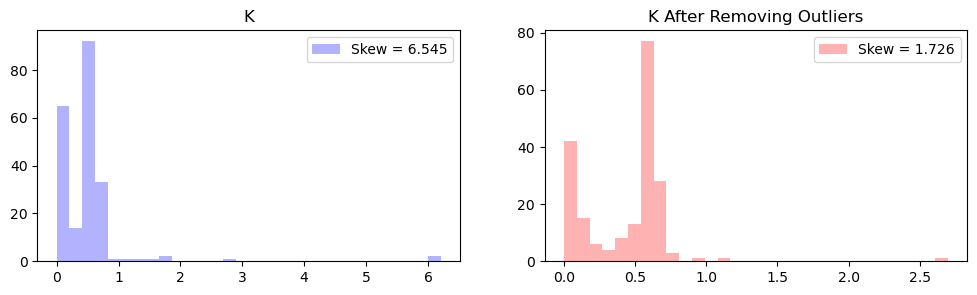

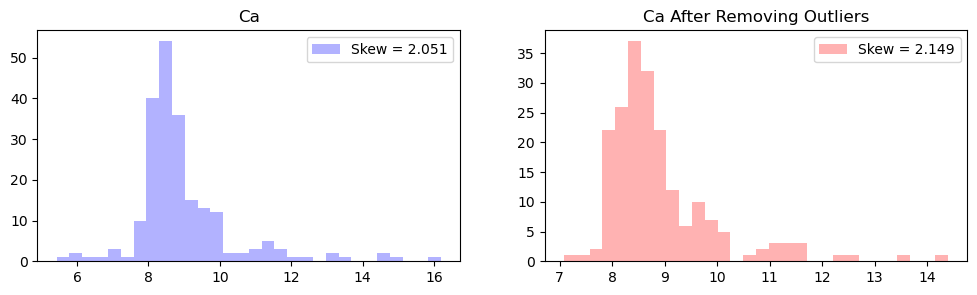

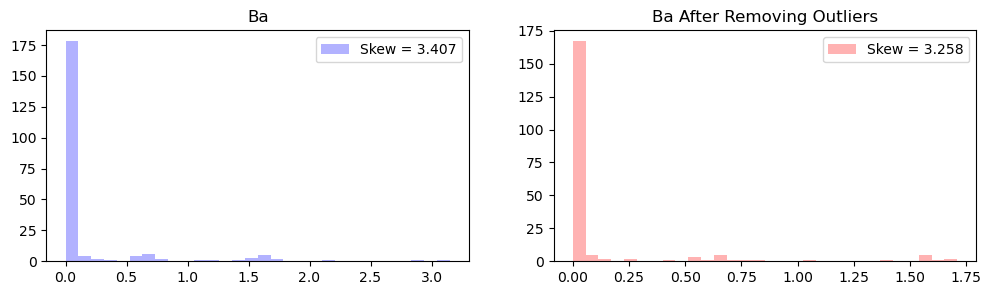

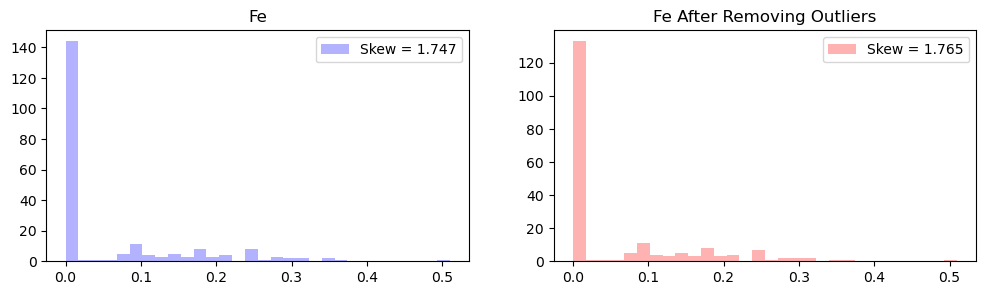

In [105]:
# Loop through each feature in the dataset
for feature in features:
    
    # Create a figure with 2 subplots (side-by-side)
    # One for original data, one after removing outliers
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))    
    
    # -------------------------
    # Plot histogram of original data
    # -------------------------
    ax[0].hist(
        glass_df[feature],          # original feature values
        color='blue', 
        bins=30, 
        alpha=0.3,                  # transparency
        label='Skew = %s' % (str(round(glass_df[feature].skew(), 3)))
    )
    
    # Set title as feature name
    ax[0].set_title(str(feature))   
    
    # Display skewness in legend
    ax[0].legend(loc=0)
    
    # -------------------------
    # Plot histogram after removing outliers
    # -------------------------
    outlier_indices = outlier_hunt(glass_df[features])
    df = glass_df.drop(outlier_indices).reset_index(drop=True)

    ax[1].hist(
        df[feature],             # feature values after outlier removal
        color='red', 
        bins=30, 
        alpha=0.3,
        label='Skew = %s' % (str(round(df[feature].skew(), 3)))
    )
    
    # Set title to indicate outliers removed
    ax[1].set_title(str(feature) + ' After Removing Outliers')
    
    # Display skewness in legend
    ax[1].legend(loc=0)
    
    # Show the figure for the current feature
    plt.show()

### 5.2 Test Train Split

In [106]:
X = df.drop('Type',axis=1)
y = df[['Type']]

**Task:** Make 20% of the data goes to testing

In [107]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2)

In [108]:
print("Shape of X_train : ",X_train.shape)
print("Shape of X_test  : ",X_test.shape)
print("Shape of y_train : ",y_train.shape)
print("Shape of y_test  : ",y_test.shape)

Shape of X_train :  (159, 9)
Shape of X_test  :  (40, 9)
Shape of y_train :  (159, 1)
Shape of y_test  :  (40, 1)


### 5.3 Standardize the Variables

Apply Standardization 

	- 1.	Standardize the feature variables using StandardScaler.
	- 2.	Ensure that:
		*The scaler is fitted only on the training data.*
		*The same transformation is applied to the test data.*
	- 3.	Store the transformed data back into X_train and X_test.

In [109]:
help(StandardScaler)

Help on class StandardScaler in module sklearn.preprocessing._data:

class StandardScaler(sklearn.base.OneToOneFeatureMixin, sklearn.base.TransformerMixin, sklearn.base.BaseEstimator)
 |  StandardScaler(*, copy=True, with_mean=True, with_std=True)
 |
 |  Standardize features by removing the mean and scaling to unit variance.
 |
 |  The standard score of a sample `x` is calculated as:
 |
 |  .. code-block:: text
 |
 |      z = (x - u) / s
 |
 |  where `u` is the mean of the training samples or zero if `with_mean=False`,
 |  and `s` is the standard deviation of the training samples or one if
 |  `with_std=False`.
 |
 |  Centering and scaling happen independently on each feature by computing
 |  the relevant statistics on the samples in the training set. Mean and
 |  standard deviation are then stored to be used on later data using
 |  :meth:`transform`.
 |
 |  Standardization of a dataset is a common requirement for many
 |  machine learning estimators: they might behave badly if the
 | 

In [110]:
std = StandardScaler()

X_train = std.fit_transform(X_train)
X_test = std.transform(X_test)

## 6. Choose the value for K?

### 6.1 Grid search for choosing the best Value of K

In K-Nearest Neighbours (KNN), the parameter k means: The number of nearest neighbors used to make a prediction.
You are given the following code intended to evaluate different values of k in a KNN classifier:

In [111]:
# Generate a list of odd k values from 1 to 39
# Odd numbers are often chosen to reduce tie votes in classification
k_list = np.arange(1, 40, 2)

# Lists to store evaluation metrics for each k
mean_scores = []     # Stores mean cross-validation accuracy
accuracy_list = []   # (Not currently used in loop)
error_rate = []      # Stores test error rate for each k

# Loop through each value of k
for i in k_list:
    
    # Create KNN model with current k
    knn = KNeighborsClassifier(n_neighbors=i)
    
    # Train the model on the training data
    knn.fit(X_train, y_train)
    
    # Predict labels on the test set
    pred_i = knn.predict(X_test)
    
    # Reshape predictions 
    pred_i = pred_i.reshape(40,1)
    
    # Perform 10-fold cross-validation on training data
    # This estimates generalization performance
    score = cross_val_score(knn, X_train, y_train, cv=10)
    
    # Store mean cross-validation accuracy
    mean_scores.append(np.mean(score))
    
    # Compute and store test error rate
    # Error rate = proportion of incorrect predictions
    error_rate.append(np.mean(pred_i != y_test))

- 1.	**Explain what happens during one iteration (one fold) of 10-fold cross-validation.**

First, the data is divided into ten equal batches, or folds. Then, the algorithm loops over these ten batches, using the fixed one as validation data and the rest as training data. Hence, the model is trained and validated ten times, each time obtaining a score value, accuracy by default. Therefore, the command `cross_val_score(knn, X_train, y_train, cv=10)` outputs an array of 10 scores, corresponding to the loop over the 10 different sets of training and validation data.

- 2.	**Why is the process repeated 10 times?**

If the question refers to why we choose 10 and not a greater or lower value, we could say it is because it is the most commonly used value for cross-validation in the literature. However, it is not necessarily the best choice for the hyperparameter value. Reducing the number of folds would result in increased bias, and increasing it would overfit the data, thereby increasing variance. Ten is a rather stable hyperparameter value that maintains a reliable bias-variance trade off.

**The following code is given to you. You should modify it to plot the error rate instead of the mean cross-validation accuracy.**

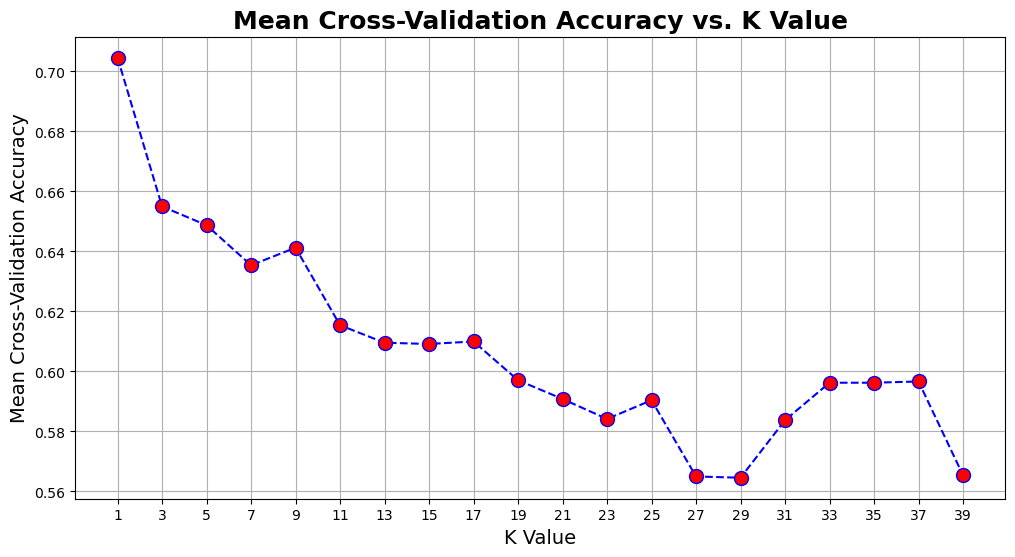

In [112]:
plt.figure(figsize=(12,6))
plt.plot(k_list, mean_scores, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Mean Cross-Validation Accuracy vs. K Value', fontsize=18, fontweight='bold')
plt.xlabel('K Value', fontsize=14)
plt.ylabel('Mean Cross-Validation Accuracy', fontsize=14)
plt.xticks(k_list)
plt.grid()
plt.show()

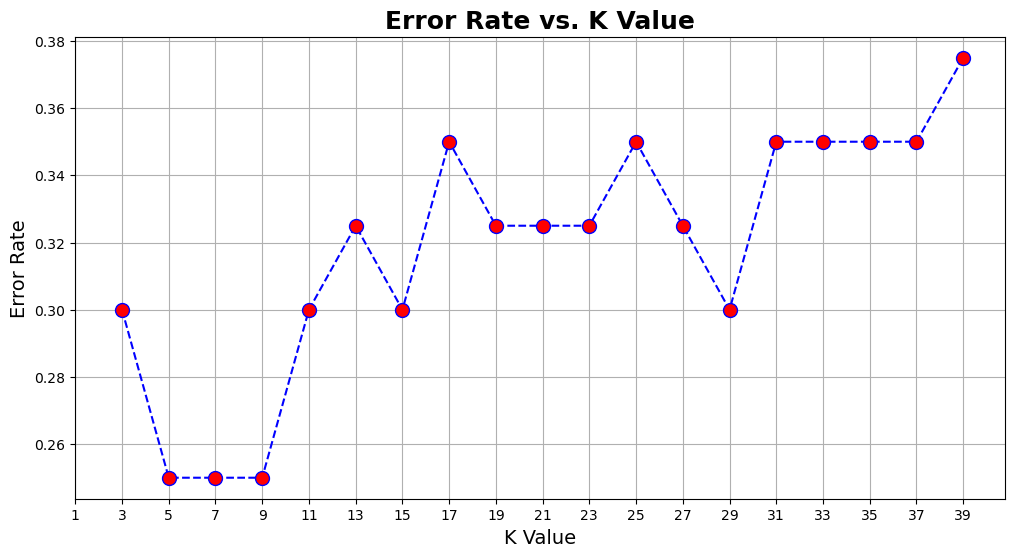

In [113]:
k_range = [i for i in range(3,40, 2)]

plt.figure(figsize=(12,6))
plt.plot(k_range, error_rate[1:], color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value', fontsize=18, fontweight='bold')
plt.xlabel('K Value', fontsize=14)
plt.ylabel('Error Rate', fontsize=14)
plt.xticks(k_list)
plt.grid()
plt.show()

In [114]:
n_neighbors = np.array([2*i+1 for i in range(1,20)])
param_grid = dict(n_neighbors=n_neighbors)
n_neighbors

array([ 3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35,
       37, 39])

In [115]:
param_grid

{'n_neighbors': array([ 3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35,
        37, 39])}

In [116]:
help(GridSearchCV)

Help on class GridSearchCV in module sklearn.model_selection._search:

class GridSearchCV(BaseSearchCV)
 |  GridSearchCV(estimator, param_grid, *, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs', error_score=nan, return_train_score=False)
 |
 |  Exhaustive search over specified parameter values for an estimator.
 |
 |  Important members are fit, predict.
 |
 |  GridSearchCV implements a "fit" and a "score" method.
 |  It also implements "score_samples", "predict", "predict_proba",
 |  "decision_function", "transform" and "inverse_transform" if they are
 |  implemented in the estimator used.
 |
 |  The parameters of the estimator used to apply these methods are optimized
 |  by cross-validated grid-search over a parameter grid.
 |
 |  Read more in the :ref:`User Guide <grid_search>`.
 |
 |  Parameters
 |  ----------
 |  estimator : estimator object
 |      This is assumed to implement the scikit-learn estimator interface.
 |      Either estimator needs

In [117]:
# Create a KNN classifier with default parameters
# (Hyperparameters like n_neighbors will be tuned via GridSearch)
model = KNeighborsClassifier()

# Create a GridSearch object
# - estimator: the base model to tune
# - param_grid: dictionary of hyperparameters to test (e.g., different k values)
# - perform 10-fold cross-validation for each parameter combination
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=10
)

# Fit GridSearch to the full dataset (X features, y target)
grid.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([ 3, 5... 37, 39])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidat

- 1. **Print `grid.best_score`, the highest mean cross-validation accuracy found during GridSearch, and the hyperparameter values that achieved the best cross-validation score, `grid.best_params`.**

- 2.  **Select best K; explain the importance of the outputs. What is the value of K for the best model?**

In [118]:
print(f"The highest mean cross-validation accuracy found during GridSearch is {grid.best_score_}.")
print(f"The hyperparameter values that achieved the best cross-valiedation score are {grid.best_params_['n_neighbors']}.")
print(f"Thus, the best estimator is {grid.best_estimator_}.")

The highest mean cross-validation accuracy found during GridSearch is 0.6634210526315789.
The hyperparameter values that achieved the best cross-valiedation score are 3.
Thus, the best estimator is KNeighborsClassifier(n_neighbors=np.int64(3)).


The importance of these results lies in the fact that, in terms of accuracy, we obtain the model that best generalises our dataset.

### 6.2 Visualizing the CV results

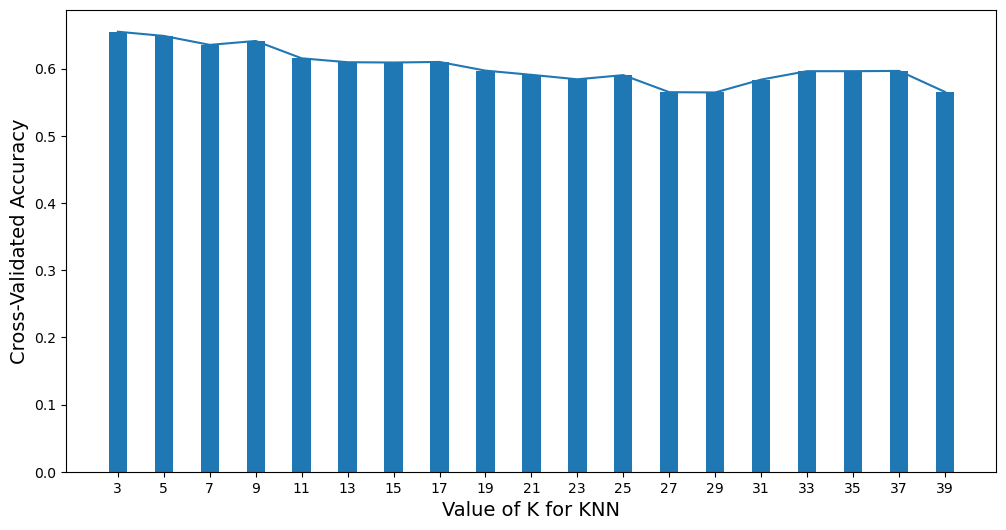

In [119]:
k_range = np.array([2*i+1 for i in range(1,20)])
k_scores = []

# use iteration to caclulator different k in models, then return the average accuracy based on the cross validation
for k in k_range:
    #Create a K-Nearest Neighbors (KNN) classifier with: n_neighbors = k
    knn = KNeighborsClassifier(n_neighbors= k)
    #perform 10-fold cross-validation on the KNN model
    #return an array called scores containing 10 accuracy values — one for each fold.
    scores = cross_val_score(knn, X_train, y_train, cv= 10)
    #compute the average cross-validation accuracy and store that average in the list k_scores.
    #Without this line, you would:
	#•	Only see raw fold scores
	#•	Not be able to compare k values easily
	#•	Not know which k performs best overall
    k_scores.append(np.mean(scores))

plt.figure(figsize=(12,6))
plt.bar(k_range, k_scores)
plt.plot(k_range, k_scores)
plt.xlabel('Value of K for KNN', fontsize = 14)
plt.ylabel('Cross-Validated Accuracy', fontsize = 14)
plt.xticks(k_range)
plt.show()

In [120]:
best_k = k_range[np.argmax(k_scores)]
print("Best K:", best_k)

Best K: 3


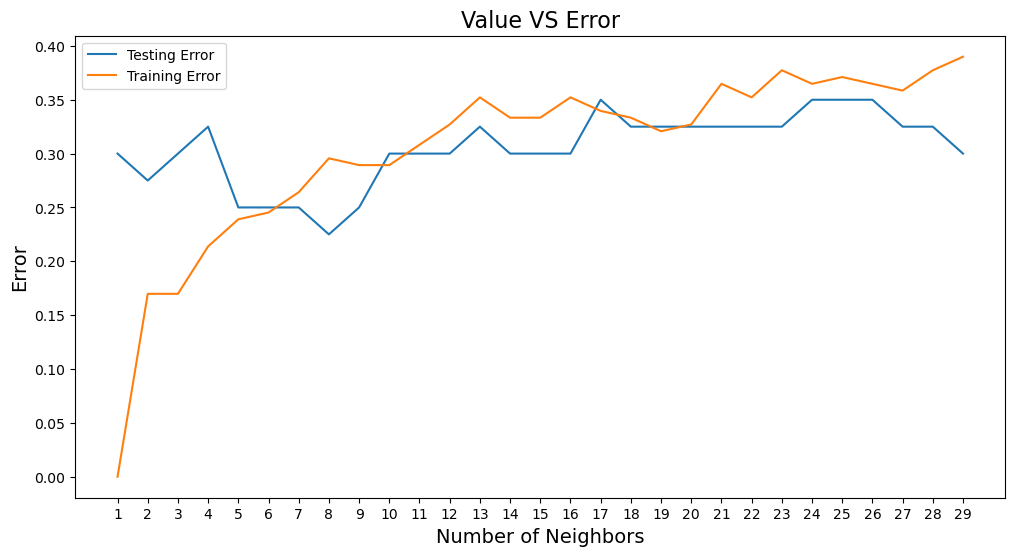

In [121]:
error1= []
error2= []
k_range = [i for i in range(1,30)]
for k in k_range:
    knn= KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)

    # Training predictions
    y_pred1= knn.predict(X_train)
    y_pred1 = y_pred1.reshape(159,1)
    error1.append(np.mean(y_train!= y_pred1))
    # Testing predictions
    y_pred2= knn.predict(X_test)
    y_pred2 = y_pred2.reshape(40,1)
    error2.append(np.mean(y_test!= y_pred2))

plt.figure(figsize=[12,6])
plt.plot(k_range, error2, label = 'Testing Error')
plt.plot(k_range, error1, label = 'Training Error')
plt.legend()
plt.title('Value VS Error', fontsize = 16)
plt.xlabel('Number of Neighbors', fontsize = 14)
plt.ylabel('Error', fontsize = 14)
plt.xticks(k_range)
plt.show()

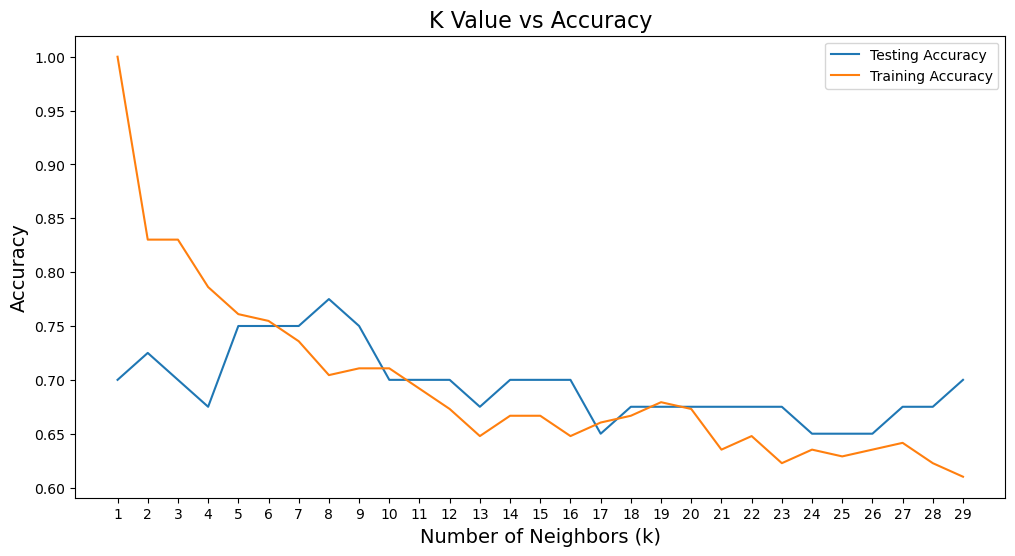

In [122]:
# Lists to store accuracy values for each k
train_accuracy = []
test_accuracy = []

# Define range of k values (1 to 29)
# Smaller k → more flexible model
# Larger k → smoother decision boundary
k_range = [i for i in range(1,30)]

# Loop through each k value, train KNN, and compute accuracy on training and test sets
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    train_accuracy.append(knn.score(X_train,y_train))
    test_accuracy.append(knn.score(X_test,y_test))

# -----------------------------
# Plot Accuracy vs K
# -----------------------------

plt.figure(figsize=(12,6))

# Plot testing accuracy curve
plt.plot(k_range, test_accuracy, label='Testing Accuracy')

# Plot training accuracy curve
plt.plot(k_range, train_accuracy, label='Training Accuracy')

# Add legend to distinguish curves
plt.legend()

# Add titles and axis labels
plt.title('K Value vs Accuracy', fontsize=16)
plt.xlabel('Number of Neighbors (k)', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)

# Show each k value on x-axis
plt.xticks(k_range)

# Display plot
plt.show()

- 1.	**Explain why training error is usually lower than testing error.**

The reason lies in the training process. Note that the parameters are computed by minimising the corresponding loss function with respect to the training data; that is, the greater the training, the closer the fit will be. Thus, although it is not true in general, the training error tends to be lower than the testing error.

- 2.	**What happens when k = 1?**

In such a case, for any point outside our training dataset, its predicted class will be that of the closest training data point to it.

- 3.	**What happens when k becomes very large?**

If K becomes sufficiently large to be, say, the number or almost the number of training data points, the predicted class of any additional point would consist of the class of the majority within its neighbours. Thus, the model would disregard the data points of the other classes, even in the case where there is one less than the dominant class or if there are none at all. This implies a significant loss of information and meaningless results. In terms of the bias variance trade off: high bias and low variance.

## 7. Applying KNN

### 7.1 Applying KNN using K=3

KNN using K = 3




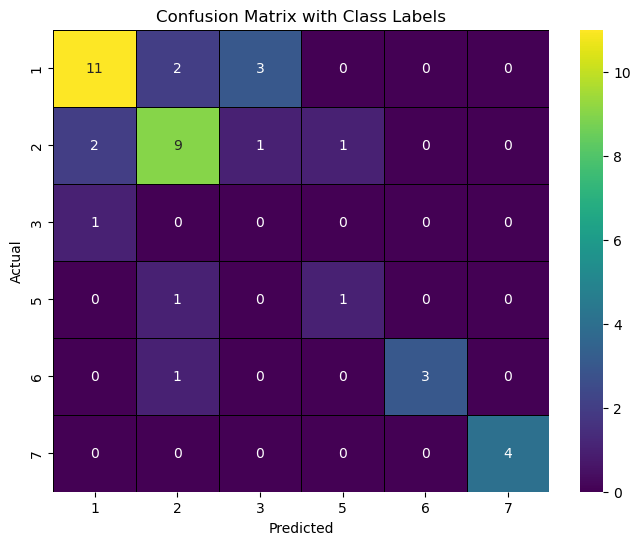



Classification Report:
              precision    recall  f1-score   support

           1       0.79      0.69      0.73        16
           2       0.69      0.69      0.69        13
           3       0.00      0.00      0.00         1
           5       0.50      0.50      0.50         2
           6       1.00      0.75      0.86         4
           7       1.00      1.00      1.00         4

    accuracy                           0.70        40
   macro avg       0.66      0.60      0.63        40
weighted avg       0.76      0.70      0.73        40



In [123]:
# Create KNN classifier with k = 3 neighbors
# k controls how many nearest points vote in classification
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model using the training data
knn.fit(X_train, y_train)

#Evaluate on Test Data (Only Once)
# Predict labels for the test dataset
pred = knn.predict(X_test)

print('KNN using K = 3')
print('\n')

# Print confusion matrix
labels = knn.classes_
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='viridis',
            linewidths=0.5, 
            linecolor='black',
            xticklabels=labels, 
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with Class Labels")
plt.show()

print('\n')

# Print classification report
# Includes precision, recall, F1-score, and support for each class
print("Classification Report:")
print(classification_report(y_test, pred))


# Important! What Does This Confusion Matrix Tell You ?

Observing the confusion matrix and the evaluation metrics, we can derive a solid conclusion about our model.

First of all, we achieve a decent accuracy of 78%. However, recall that this value could turn out to be misleading and, in fact, it is in this case; note that our model performs horribly with type 3 data, with no correct predictions of this type. Furthermore, not only for type 3 data, but for every class, misclassification lies in incorrect type 1 or type 2 results. We previously advanced that an outcome like this could appear since the data was significantly imbalanced, containing much more type 1 and 2 data than the rest of the classes.

On the other hand, we note that it successfully behaves for the rest of the types, with remarkable recall values for type 1, 2, 5, 6, and 7 data, standing out type 5 and 6 with 100% accuracy, and type 1 with 0.93 recall.

Overall, if we do not need to regard type 3 data for our results, the model has decent performance and could represent a useful tool.

### 7.2 Applying KNN using K=5

In [124]:
# Create a KNN classifier with k = 5 neighbors

KNN using K = 5




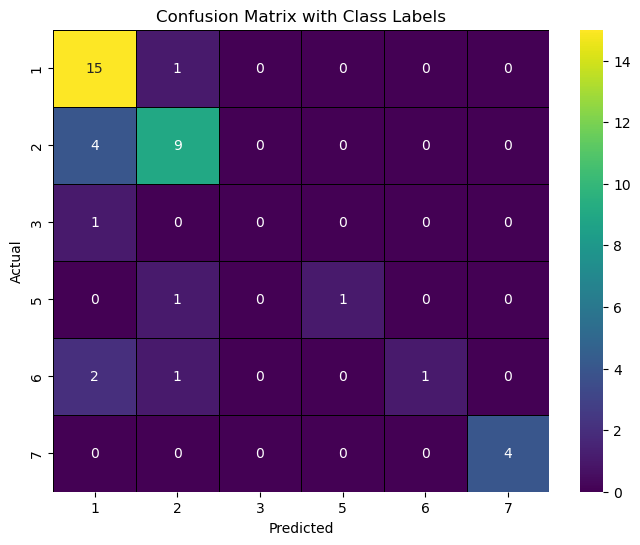



Classification Report:
              precision    recall  f1-score   support

           1       0.68      0.94      0.79        16
           2       0.75      0.69      0.72        13
           3       0.00      0.00      0.00         1
           5       1.00      0.50      0.67         2
           6       1.00      0.25      0.40         4
           7       1.00      1.00      1.00         4

    accuracy                           0.75        40
   macro avg       0.74      0.56      0.60        40
weighted avg       0.77      0.75      0.72        40



In [125]:
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model using the training data
knn.fit(X_train, y_train)

#Evaluate on Test Data (Only Once)
# Predict labels for the test dataset
pred = knn.predict(X_test)

print('KNN using K = 5')
print('\n')

# Print confusion matrix
labels = knn.classes_
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='viridis',
            linewidths=0.5, 
            linecolor='black',
            xticklabels=labels, 
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with Class Labels")
plt.show()

print('\n')

# Print classification report
# Includes precision, recall, F1-score, and support for each class
print("Classification Report:")
print(classification_report(y_test, pred))


As expected after the Grid Search evaluations, the performance decreases. We note that one data point correctly classified by 3-NN from type 3 and 5 is now misclassified by 5-NN.

## 8. Conclusion:

In this notebook, we considered a classification problem regarding glass data. We firstly visualised, understood, and manipulated the dataset to later be capable of making sense of the obtained results and justifying our conclusions.

We particularly tackled this problem through KNN, but other classification algorithms could have been used. To maximise our model performance, we made use of cross-validation through grid search and obtained the hyperparameter which best (in the sense of accuracy) fit our data. We thus applied 3-NN and then compared its results with the weaker model 5-NN.

By delving into the core of the algorithm and reflecting on our results at each step of the notebook, we built a structured understanding of the model as a whole and derived meaningful answers to our initial problem.

# THE END!!!  now apply the same code to the zoo data in a different notebook.